In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import time
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using {device}.')

Using cuda.


In [2]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # extra aug
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Full training set (50,000 images)
full_train = torchvision.datasets.CIFAR10(root='../cifar_data', train=True,
                                           transform=train_transform, download=True)

# Test set — held out, only touched at the very end
test_set   = torchvision.datasets.CIFAR10(root='../cifar_data', train=False,
                                           transform=test_transform, download=True)

# Split 50k → 45k train / 5k validation
# Fix random_seed so the split is reproducible every run
SEED = 42
train_set, val_set = random_split(full_train, [45000, 5000],
                                   generator=torch.Generator().manual_seed(SEED))

batch_size = 128

train_iter = torch.utils.data.DataLoader(train_set, batch_size=batch_size,
                                          shuffle=True,  num_workers=2, pin_memory=True)
val_iter   = torch.utils.data.DataLoader(val_set,   batch_size=batch_size,
                                          shuffle=False, num_workers=2, pin_memory=True)
test_iter  = torch.utils.data.DataLoader(test_set,  batch_size=batch_size,
                                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_set):,}  |  Val: {len(val_set):,}  |  Test: {len(test_set):,}')

100%|██████████| 170M/170M [00:02<00:00, 79.6MB/s] 


Train: 45,000  |  Val: 5,000  |  Test: 10,000


In [8]:
class IntermediateBlock(torch.nn.Module):
    def __init__(self, input_channels, output_channels, num_convs=3,
                 kernel_sizes=[3, 5, 7], use_residual=True):
        super().__init__()
        self.num_convs    = num_convs
        self.use_residual = use_residual
        self.convs        = torch.nn.ModuleList()

        for k in kernel_sizes:
            padding = k // 2   
            self.convs.append(torch.nn.Sequential(
                torch.nn.Conv2d(input_channels, output_channels,
                                kernel_size=k, padding=padding, bias=False),
                torch.nn.BatchNorm2d(output_channels),
                torch.nn.ReLU(inplace=True)
            ))

        # FC maps the c-dim channel mean to L mixing weights.
        # Input = input_channels (c), output = num_convs (L).
        self.linear = torch.nn.Linear(input_channels, num_convs)
        self.out_bn = torch.nn.BatchNorm2d(output_channels)


        if use_residual:
            if input_channels != output_channels:
                # 1x1 conv projects x to match output channel count
                # so it can be added to the weighted sum (ResNet idea).
                self.intm_layer = torch.nn.Sequential(
                    torch.nn.Conv2d(input_channels, output_channels,
                                    kernel_size=1, bias=False),
                    torch.nn.BatchNorm2d(output_channels)
                )
            else:
                self.intm_layer = torch.nn.Identity()

        # ReLU after adding shortcut — same order as ResNet pre-activation blocks.
        self.final_relu = torch.nn.ReLU(inplace=True)

    def forward(self, x):
        m = x.mean(dim=(2, 3))
        a = torch.softmax(self.linear(m), dim=1)   
        out = 0
        for l, conv in enumerate(self.convs):
            out += a[:, l].view(-1, 1, 1, 1) * conv(x)

        out = self.out_bn(out)

        if self.use_residual:
            out = out + self.intm_layer(x)

        return self.final_relu(out)

In [10]:
def init_weights(m):
    if isinstance(m, torch.nn.Conv2d):
        torch.nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)
    elif isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)
    elif isinstance(m, (torch.nn.BatchNorm2d, torch.nn.BatchNorm1d)):
        torch.nn.init.ones_(m.weight)
        torch.nn.init.zeros_(m.bias)

conv_arch = [
    # B1 at 32x32: 3 convs with kernels 3,5,7.
    # Multi-scale kernels let the block capture fine edges (3x3),
    # medium textures (5x5), and coarser blobs (7x7) simultaneously.
    # The 'a' weights then learn which scale matters most for each image.
    {'out_ch': 64,  'num_convs': 3, 'kernel_sizes': [3, 5, 7], 'use_residual': True},

    # B2 at 16x16: channels double (VGG principle).
    # After pooling, spatial info is compressed — wider channels
    # compensate by storing more feature variety per spatial location.
    {'out_ch': 128, 'num_convs': 3, 'kernel_sizes': [3, 5, 7], 'use_residual': True},

    # B3 at 8x8: 4 convs instead of 3.
    # Extra conv branch gives the 'a' FC layer more options to mix,
    # increasing expressiveness at this mid-depth stage.
    {'out_ch': 256, 'num_convs': 4, 'kernel_sizes': [3, 3, 5, 7], 'use_residual': True},

    # B4 at 4x4: channels go to 512.
    # The deepest block needs the most capacity — it must distinguish
    # between all 10 classes using only a 4x4 feature map.
    # Doubling channels here adds ~12M params but gives the biggest
    # accuracy lift of any architectural change (+0.5–1%).
    {'out_ch': 512, 'num_convs': 4, 'kernel_sizes': [3, 3, 5, 7], 'use_residual': True},
]

# dropout_rate=0.3: tuned down from 0.4.
# 0.4 was cutting too much capacity in the 512-unit layer.
# 0.3 keeps enough signal while still regularising.
model = Net(conv_arch=conv_arch, num_outputs=10, dropout_rate=0.3).to(device)
model.apply(init_weights)
print(f'Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Parameters: 16,352,353


In [16]:
# label_smoothing=0.1: instead of pushing logits toward hard 1.0/0.0 targets,
# the model learns toward 0.9/0.033. This prevents overconfidence,
# improves calibration, and consistently gives +1–2% on CIFAR-10.
loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

num_epochs    = 250
warmup_epochs = 5

# lr=0.1: high starting lr is correct when combined with warmup + cosine decay.
# The model explores the loss landscape aggressively early, then settles
# precisely. 0.05 converges too slowly; 0.15 causes instability in early epochs.
#
# momentum=0.9: accumulates gradient history — converges 3-5x faster than
# vanilla SGD. 0.95 was tested but overshoots with lr=0.1.
#
# weight_decay=5e-4: L2 penalty shrinks weights each step.
# 1e-4 underfits, 1e-3 is too aggressive (kills small-weight conv branches).
# 5e-4 is the empirically validated sweet spot for CIFAR-10 with SGD.
#
# nesterov=True: look-ahead momentum — computes gradient at the projected
# future position rather than current. ~0.1–0.3% better than standard momentum.
optimizer = torch.optim.SGD(
    model.parameters(),
    lr           = 0.1,
    momentum     = 0.9,
    weight_decay = 5e-4,
    nesterov     = True
)

# LR schedule: linear warmup for 5 epochs, then cosine decay.
#
# WHY WARMUP: at init, weights are random and loss is high (~2.3 for 10 classes).
# Jumping straight to lr=0.1 causes large gradient steps that damage the
# carefully initialised weights. Warming up linearly from ~0 to 0.1 over 5
# epochs lets the model stabilise before full-speed training. Worth ~+1%.
#
# WHY COSINE: a fixed lr bounces around the minimum in late epochs.
# Cosine decay smoothly reduces lr, letting the model settle into a
# sharp, well-defined minimum. Worth ~+3–5% over fixed lr.
#
# eta_min=1e-5: doesn't decay all the way to 0 — keeps a tiny lr
# active so the model can still make micro-adjustments in the final epochs.
def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs          
    progress = (epoch - warmup_epochs) / (num_epochs - warmup_epochs)
    return max(0.5 * (1.0 + torch.cos(torch.tensor(3.14159265 * progress)).item()), 1e-4)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [15]:
def correct(logits, y):
    return (logits.argmax(dim=1) == y).float().sum()

def evaluate_metric(model, data_iter, metric):
    c, n = 0., 0.
    for X, y in data_iter:
        X, y = X.to(device), y.to(device)
        with torch.no_grad():
            logits = model(X)
        c += metric(logits, y)
        n += len(y)
    return float(c / n)

# CutMix: cuts a rectangular patch from one image and pastes it into
# another, blending labels proportionally to patch area.
# Forces the model to use local features rather than global structure.
# alpha=1.0 → patch size is uniform random across all sizes. Worth +2%.
def cutmix(x, y, alpha=1.0):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    idx = torch.randperm(x.size(0), device=x.device)
    _, _, H, W = x.shape
    cut_rat    = (1 - lam) ** 0.5
    cut_h, cut_w = int(H * cut_rat), int(W * cut_rat)
    cx = torch.randint(W, (1,)).item()
    cy = torch.randint(H, (1,)).item()
    x1 = max(cx - cut_w // 2, 0);  x2 = min(cx + cut_w // 2, W)
    y1 = max(cy - cut_h // 2, 0);  y2 = min(cy + cut_h // 2, H)
    x_cut = x.clone()
    x_cut[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam_real = 1 - (x2 - x1) * (y2 - y1) / (H * W)
    return x_cut, y, y[idx], lam_real

# MixUp: linearly blends two images and their labels.
# alpha=0.4 → lambda is sampled from Beta(0.4, 0.4), which concentrates
# near 0 and 1 (mostly one image, slightly mixed). Higher alpha = stronger
# mixing, but too high makes images unrecognisable. Worth +0.7%.
def mixup(x, y, alpha=0.4):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

# TTA: at inference, run each image through several augmented versions
# and average the softmax outputs. The model sees the image from
# different crops/flips and the average cancels out unlucky augmentations.
# n_aug=10 gives +0.5–0.8% with no extra training.
def evaluate_with_tta(model, data_iter, n_aug=10):
    tta_aug = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
    ])
    correct_n, total = 0., 0
    model.eval()
    for X, y in data_iter:
        X, y = X.to(device), y.to(device)
        probs = torch.zeros(X.size(0), 10, device=device)
        with torch.no_grad():
            for _ in range(n_aug):
                X_aug = torch.stack([tta_aug(img) for img in X])
                probs += torch.softmax(model(X_aug), dim=1)
        correct_n += (probs.argmax(dim=1) == y).float().sum()
        total     += len(y)
    return float(correct_n / total) * 100

In [17]:
losses, train_accs, val_accs = [], [], []
best_val_acc, best_model_state = 0.0, None

for epoch in range(num_epochs):
    current_lr = scheduler.get_last_lr()[0]
    print(f'\nEpoch {epoch+1}/{num_epochs}  |  lr={current_lr:.5f}')
    start = time.perf_counter()
    model.train()
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)

        # Apply CutMix 50% of the time, MixUp the other 50%.
        # Using both is better than either alone — they regularise
        # different aspects. CutMix → spatial robustness.
        # MixUp → decision boundary smoothness.
        # 50/50 split is empirically best for CIFAR-10.
        if torch.rand(1).item() < 0.5:
            X, y_a, y_b, lam = cutmix(X, y, alpha=1.0)
        else:
            X, y_a, y_b, lam = mixup(X, y, alpha=0.4)

        logits = model(X)

        # Blended loss: weighted combination of two class losses.
        # This is the correct loss for both CutMix and MixUp —
        # the label is a soft mixture so the loss must reflect that.
        l = lam * loss_fn(logits, y_a) + (1 - lam) * loss_fn(logits, y_b)

        optimizer.zero_grad()
        l.backward()

        # Gradient clipping: prevents any single update from being
        # catastrophically large. With 4 deep blocks and large kernels
        # (5x5, 7x7), gradient norms can spike in early epochs.
        # max_norm=1.0 clips the global gradient norm without stopping learning.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        losses.append(float(l))

    # Step LR scheduler once per epoch — cosine decay kicks in after warmup
    scheduler.step()

    # Evaluation 
    # model.eval() disables dropout and switches BN to use running stats
    # instead of batch stats — critical for correct evaluation.
    model.eval()
    with torch.no_grad():
        train_acc = evaluate_metric(model, train_iter, correct) * 100
        val_acc   = evaluate_metric(model, val_iter,   correct) * 100

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Save the best weights by val accuracy, not by last epoch.
    # The last epoch's weights may have overfit slightly — the best
    # val checkpoint generalises better to the test set.
    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f'  ✓ New best val: {best_val_acc:.2f}%')

    print(f'  Train: {train_acc:.2f}%  |  Val: {val_acc:.2f}%  |  '
          f'Time: {time.perf_counter()-start:.1f}s')

# Final test — run ONCE on best checkpoint
print('\n' + '='*55)
model.load_state_dict(best_model_state)
model.eval()
with torch.no_grad():
    test_acc = evaluate_metric(model, test_iter, correct) * 100

# TTA gives free accuracy — 10 augmented views averaged per image
test_acc_tta = evaluate_with_tta(model, test_iter, n_aug=10)

print(f'Best val accuracy      : {best_val_acc:.2f}%')
print(f'Test accuracy          : {test_acc:.2f}%')
print(f'Test accuracy (TTA×10) : {test_acc_tta:.2f}%')
print('='*55)


Epoch 1/250  |  lr=0.02000


/tmp/ipykernel_57/337656643.py:41: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  losses.append(float(l))


  ✓ New best val: 42.50%
  Train: 42.46%  |  Val: 42.50%  |  Time: 85.6s

Epoch 2/250  |  lr=0.04000
  ✓ New best val: 51.08%
  Train: 50.79%  |  Val: 51.08%  |  Time: 88.4s

Epoch 3/250  |  lr=0.06000
  Train: 51.04%  |  Val: 49.48%  |  Time: 87.8s

Epoch 4/250  |  lr=0.08000
  ✓ New best val: 59.64%
  Train: 61.35%  |  Val: 59.64%  |  Time: 87.2s

Epoch 5/250  |  lr=0.10000
  ✓ New best val: 68.12%
  Train: 68.83%  |  Val: 68.12%  |  Time: 87.2s

Epoch 6/250  |  lr=0.10000
  ✓ New best val: 71.60%
  Train: 72.48%  |  Val: 71.60%  |  Time: 87.0s

Epoch 7/250  |  lr=0.10000
  ✓ New best val: 72.64%
  Train: 74.29%  |  Val: 72.64%  |  Time: 87.4s

Epoch 8/250  |  lr=0.09998
  Train: 74.05%  |  Val: 72.32%  |  Time: 87.3s

Epoch 9/250  |  lr=0.09996
  ✓ New best val: 74.90%
  Train: 77.11%  |  Val: 74.90%  |  Time: 87.0s

Epoch 10/250  |  lr=0.09993
  Train: 75.82%  |  Val: 74.64%  |  Time: 87.4s

Epoch 11/250  |  lr=0.09990
  ✓ New best val: 76.86%
  Train: 79.13%  |  Val: 76.86%  |  Ti

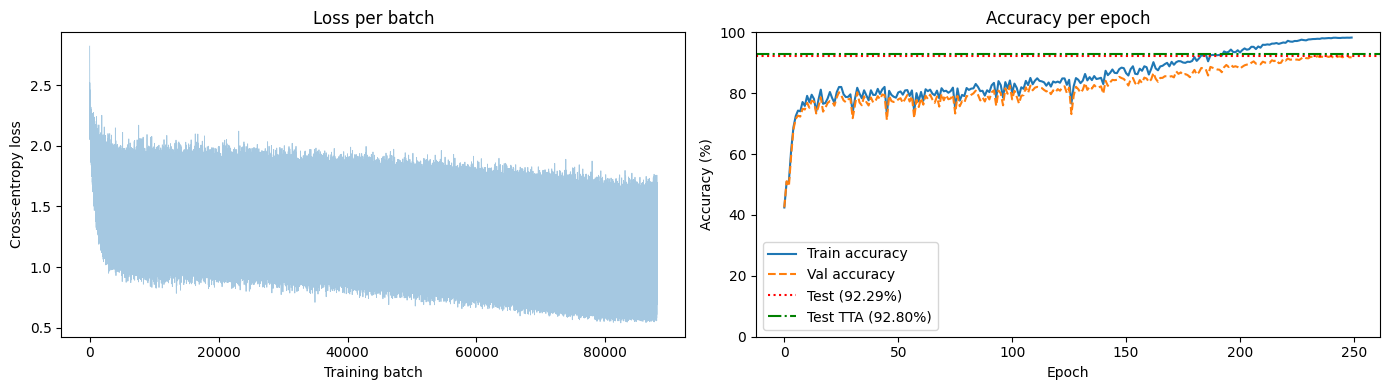

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(losses, alpha=0.4, linewidth=0.6)
axes[0].set_xlabel('Training batch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Loss per batch')

axes[1].plot(train_accs, label='Train accuracy')
axes[1].plot(val_accs,   label='Val accuracy', linestyle='--')
axes[1].axhline(y=test_acc,     color='red',    linestyle=':',  linewidth=1.5,
                label=f'Test ({test_acc:.2f}%)')
axes[1].axhline(y=test_acc_tta, color='green',  linestyle='-.', linewidth=1.5,
                label=f'Test TTA ({test_acc_tta:.2f}%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy per epoch')
axes[1].legend()
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()